In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

In [3]:
import plotly.express as px
import nbformat
print(nbformat.__version__)

5.10.4


In [4]:
departure = pd.read_csv("USCarrier_departures.csv")

In [5]:
departure.head()

,Period,Total
0,18-Jan,735065
1,18-Feb,675694
2,18-Mar,786560
3,18-Apr,779993
4,18-May,813120


In [6]:
departure.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Period  96 non-null     object
 1   Total   96 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.6+ KB


In [7]:
departure.dropna(inplace=True) # Modify the original DataFrame directly instead of creating a new one.

In [8]:
departure['Period']

0     18-Jan
1     18-Feb
2     18-Mar
3     18-Apr
4     18-May
       ...  
91    25-Aug
92    25-Sep
93    25-Oct
94    25-Nov
95    25-Dec
Name: Period, Length: 96, dtype: object

In [9]:
#convert to datetime
departure['Period'] = pd.to_datetime(departure['Period'], format='%y-%b')

In [19]:
departure.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Period  96 non-null     datetime64[ns]
 1   Total   96 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 1.6 KB


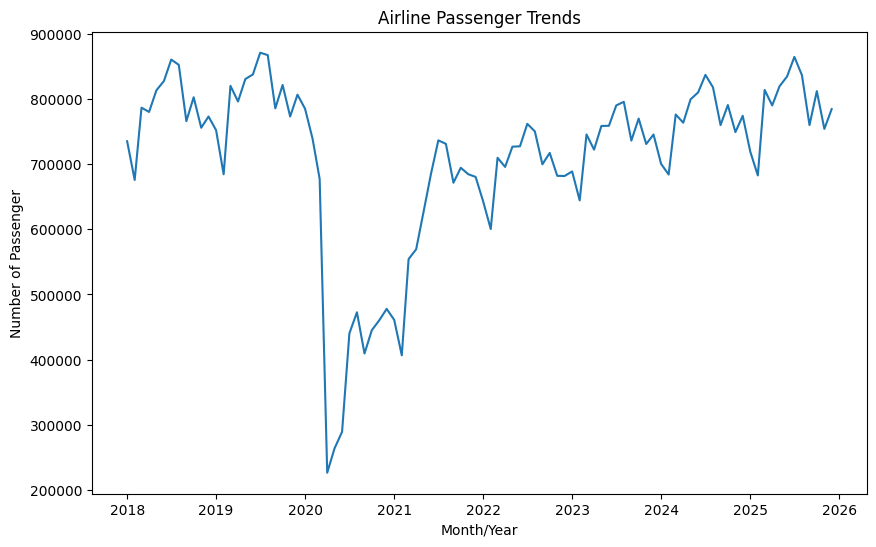

In [11]:
plt.figure(figsize=(10,6))

plt.plot(departure['Period'], departure['Total'])#.sort_values(ascending=True)

plt.title("Airline Passenger Trends")
plt.xlabel("Month/Year")
plt.ylabel("Number of Passenger")

plt.show()

In [16]:
departure['Total'] = departure['Total'].round(0)

In [20]:
#fig = px.line(df_east_africa, x='year', y='gdpPercap', color='country',
#              title = 'GDP Per Capita Over Time in EA')

fig = px.line(departure, x='Period', y='Total', title='Airline Flight Volume', markers=True)
fig.update_layout(xaxis_title='Month/Year', yaxis_title='Number of Total Flights (Monthly)', 
                  width=800,  height=600, yaxis_tickformat=',.0f' )


fig.show()